# 01 · Exploratory analysis: Lahore air quality

**Stakeholder:** a school administrator / small-business owner / city health desk in Lahore.
**Business question:** *When will the air be bad enough that we should change plans, and how far ahead can we know?*
**Success KPIs:** (1) catch "Unhealthy" hours (PM2.5 ≥ 55.5 µg/m³) ahead of time - alert recall & precision;
(2) beat the "same as yesterday" rule of thumb on MAE at every horizon; (3) honest uncertainty (80% band ≈ 80% coverage).

**Data:** Open-Meteo Air Quality (CAMS model output) + ERA5 weather, hourly, Aug 2022 → today. CC BY 4.0. No API key.

In [1]:
import json, pandas as pd, numpy as np
from aqforecast import ingest, quality, viz, aqi, config as C
raw = ingest.load_history()
report = quality.check(raw)
print(json.dumps({k: v for k, v in report.items() if k != "missing_pct"}, indent=1))
pd.Series(report["missing_pct"]).sort_values(ascending=False).head(6).to_frame("% missing")

{
 "rows": 36432,
 "start": "2022-08-01 00:00:00",
 "end": "2026-09-26 23:00:00",
 "duplicate_timestamps": 0,
 "missing_hours": 0,
 "out_of_range": {
  "ozone": 37
 }
}


,% missing
boundary_layer_height,11.989
aerosol_optical_depth,0.211
carbon_monoxide,0.211
nitrogen_dioxide,0.211
dust,0.211
ozone,0.211


**Data-quality findings**
* No duplicate or missing timestamps; 77 h at the very start of the pollutant series are empty (dropped).
* 37 ozone readings exceed the physically-plausible cap (1000 µg/m³) and are nulled by `quality.clean`.
* `boundary_layer_height` is missing for Jan-Jun 2024 in the archive API (~12%). LightGBM handles NaN natively,
  so I keep the feature rather than throw away a physically important driver.

In [2]:
df = quality.clean(raw)
df = df.loc[df.pm2_5.first_valid_index():]
df.pm2_5.describe().round(1).to_frame("PM2.5 µg/m³").T

,count,mean,std,min,25%,50%,75%,max
PM2.5 µg/m³,36355.0,70.0,48.9,0.5,37.1,54.7,86.6,365.1


In [3]:
# Share of hours in each AQI category - written in SQL (DuckDB)
import duckdb
con = duckdb.connect()
con.register("aq", df.reset_index())
cats = con.execute('''
    SELECT CASE WHEN pm2_5 <= 9.0 THEN '1 Good' WHEN pm2_5 <= 35.4 THEN '2 Moderate'
                WHEN pm2_5 <= 55.4 THEN '3 USG' WHEN pm2_5 <= 125.4 THEN '4 Unhealthy'
                WHEN pm2_5 <= 225.4 THEN '5 Very Unhealthy' ELSE '6 Hazardous' END AS category,
           count(*) AS hours, round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM aq WHERE pm2_5 IS NOT NULL GROUP BY 1 ORDER BY 1''').df()
cats

,category,hours,pct
0,1 Good,120,0.3
1,2 Moderate,8036,22.1
2,3 USG,10353,28.5
3,4 Unhealthy,13282,36.5
4,5 Very Unhealthy,3982,11.0
5,6 Hazardous,582,1.6


More than half of all hours are already 'Unhealthy' or worse - this is a chronic, high-base-rate problem, which is why a *forecast* of the worst days (and of the rare clean windows) is valuable.

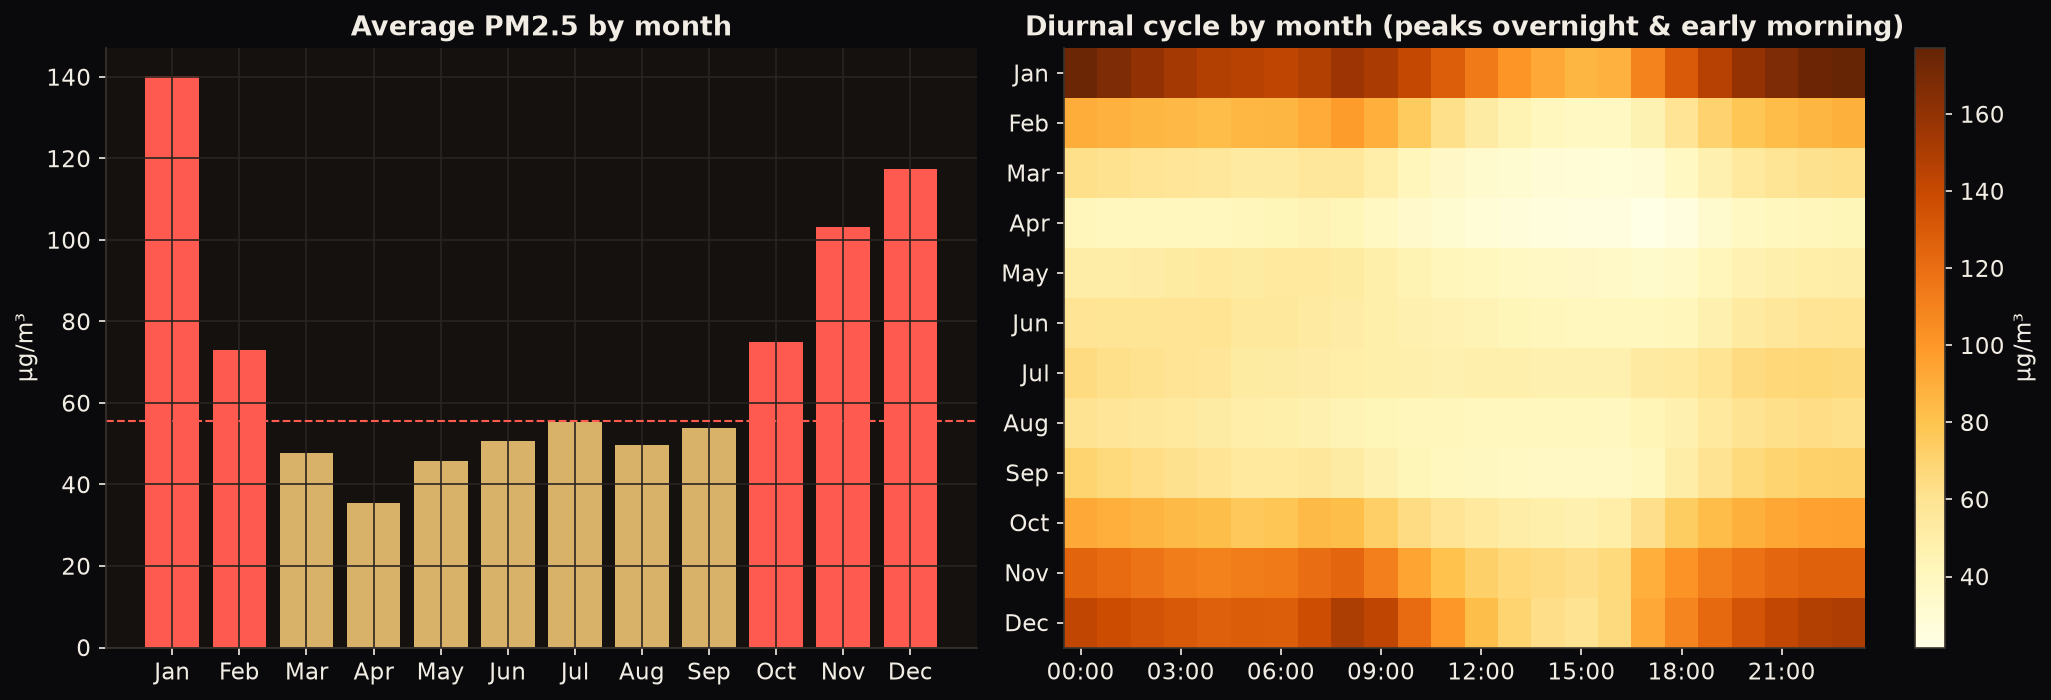

In [4]:
from aqforecast.config import FIGURES_DIR
from IPython.display import Image
viz.plot_seasonality(df, FIGURES_DIR / "01_seasonality.png")
Image(str(FIGURES_DIR / "01_seasonality.png"))

**Insight:** a very strong seasonal signal (Nov-Feb smog season) and a diurnal cycle that peaks overnight/early morning when the boundary layer collapses. Calendar features + hour-of-day are therefore essential.

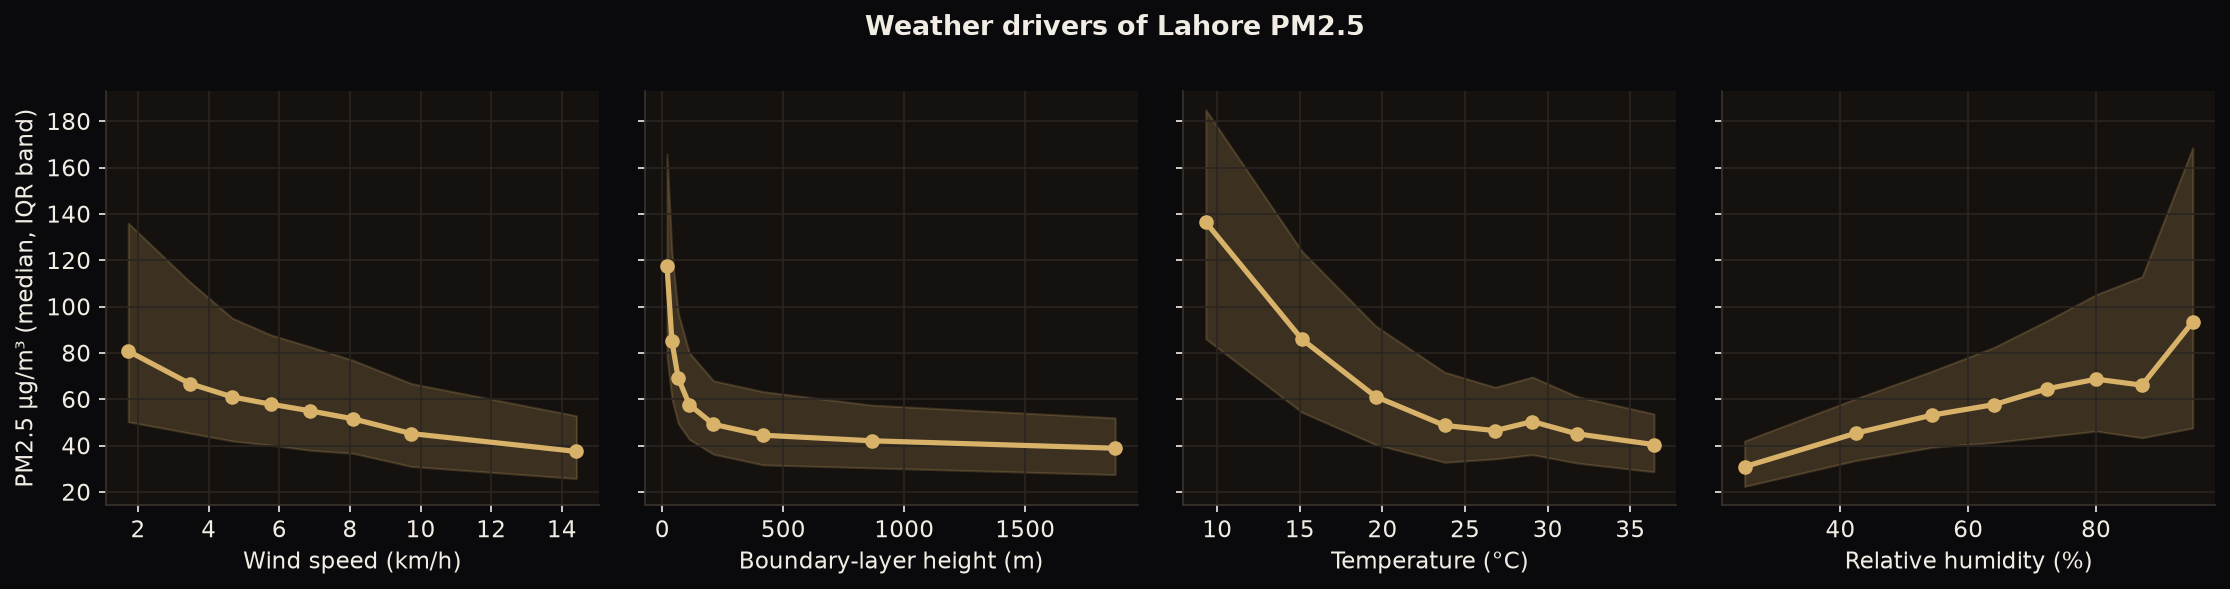

In [5]:
viz.plot_drivers(df, FIGURES_DIR / "02_weather_drivers.png")
Image(str(FIGURES_DIR / "02_weather_drivers.png"))

**Insight:** low wind, shallow boundary layer, cool temperature and high humidity co-occur with the worst pollution - the classic winter-inversion signature. These weather variables (available from weather forecasts) let the model anticipate *changes* days ahead, not just extrapolate.

In [6]:
from statsmodels.tsa.stattools import acf
a = acf(df.pm2_5.dropna().iloc[-24*365:], nlags=24*7)
pd.Series({"lag 1h": a[1], "lag 6h": a[6], "lag 24h": a[24], "lag 72h": a[72], "lag 168h": a[168]}).round(3).to_frame("autocorrelation")

,autocorrelation
lag 1h,0.978
lag 6h,0.692
lag 24h,0.819
lag 72h,0.699
lag 168h,0.598


**Modelling decisions from the EDA**
1. Strong persistence (ACF 0.97 at 1 h) → forecast the *change from now* rather than the level (validated: much better at short horizons).
2. Clear daily seasonality → seasonal-naive baselines ("same hour yesterday", "mean of last 3 days at that hour") are the bar to beat.
3. Skewed target → work in `log1p(PM2.5)`; quantile models are invariant to this transform.
4. Time-ordered data → blocked expanding-window CV with a 72 h gap and a final hold-out **year** (contains a full smog season).